<a href="https://colab.research.google.com/github/will2bless1140/Data-science/blob/main/PYSPARK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# exploratory data analysis (EDA) on your dataset to gain a better understanding of the features and their relationships with the target variable.

In [ ]:
#To check the distribution of the target variable, you can use descriptive statistics and visualizations such as histograms, density plots, and box plots. This will give you an idea of the central tendency, spread, and shape of the distribution.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# this is a data set of weather in Austrailia
data = pd.read_csv('database.csv')
data.head()

,UNIQUE KEY,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,...,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 3 TYPE,VEHICLE 4 TYPE,VEHICLE 5 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,VEHICLE 3 FACTOR,VEHICLE 4 FACTOR,VEHICLE 5 FACTOR
0,3146911,01/01/2015,0:20,QUEENS,11358.0,40.751847,-73.787862,"(40.7518471, -73.787862)",47 AVENUE,193 STREET,...,SPORT UTILITY/STATION WAGON,NaN,NaN,NaN,NaN,TRAFFIC CONTROL DISREGARDED,NaN,NaN,NaN,NaN
1,3146180,01/01/2015,0:20,NaN,NaN,40.771289,-73.946693,"(40.7712888, -73.9466928)",NaN,NaN,...,PASSENGER VEHICLE,NaN,NaN,NaN,NaN,ANIMALS ACTION,NaN,NaN,NaN,NaN
2,3146384,01/01/2015,0:21,BROOKLYN,11205.0,40.689445,-73.955121,"(40.6894449, -73.9551212)",BEDFORD AVENUE,LAFAYETTE AVENUE,...,PASSENGER VEHICLE,UNKNOWN,NaN,NaN,NaN,FATIGUED/DROWSY,UNSPECIFIED,NaN,NaN,NaN
3,3146013,01/01/2015,0:30,BROOKLYN,11213.0,40.673845,-73.925080,"(40.6738445, -73.9250801)",BUFFALO AVENUE,SAINT MARKS AVENUE,...,BUS,PASSENGER VEHICLE,NaN,NaN,NaN,LOST CONSCIOUSNESS,NaN,NaN,NaN,NaN
4,3146120,01/01/2015,0:33,NaN,NaN,NaN,NaN,NaN,RICHMOND TERRACE,SOUTH AVENUE,...,UNKNOWN,PASSENGER VEHICLE,NaN,NaN,NaN,UNSPECIFIED,UNSPECIFIED,NaN,NaN,NaN


In [ ]:
print('data has %d rows and %d columns' % data.shape)

data has 477732 rows and 29 columns


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477732 entries, 0 to 477731
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   UNIQUE KEY           477732 non-null  int64  
 1   DATE                 477732 non-null  object 
 2   TIME                 477732 non-null  object 
 3   BOROUGH              338390 non-null  object 
 4   ZIP CODE             338329 non-null  float64
 5   LATITUDE             356600 non-null  float64
 6   LONGITUDE            356600 non-null  float64
 7   LOCATION             356600 non-null  object 
 8   ON STREET NAME       364552 non-null  object 
 9   CROSS STREET NAME    335574 non-null  object 
 10  OFF STREET NAME      58511 non-null   object 
 11  PERSONS INJURED      477732 non-null  int64  
 12  PERSONS KILLED       477732 non-null  int64  
 13  PEDESTRIANS INJURED  477732 non-null  int64  
 14  PEDESTRIANS KILLED   477732 non-null  int64  
 15  CYCLISTS INJURED 

In [ ]:
data.isnull().sum()

UNIQUE KEY                  0
DATE                        0
TIME                        0
BOROUGH                139342
ZIP CODE               139403
LATITUDE               121132
LONGITUDE              121132
LOCATION               121132
ON STREET NAME         113180
CROSS STREET NAME      142158
OFF STREET NAME        419221
PERSONS INJURED             0
PERSONS KILLED              0
PEDESTRIANS INJURED         0
PEDESTRIANS KILLED          0
CYCLISTS INJURED            0
CYCLISTS KILLED             0
MOTORISTS INJURED           0
MOTORISTS KILLED            0
VEHICLE 1 TYPE           3955
VEHICLE 2 TYPE          80937
VEHICLE 3 TYPE         447468
VEHICLE 4 TYPE         470901
VEHICLE 5 TYPE         476049
VEHICLE 1 FACTOR         3249
VEHICLE 2 FACTOR        62331
VEHICLE 3 FACTOR       446094
VEHICLE 4 FACTOR       470500
VEHICLE 5 FACTOR       475970
dtype: int64

In [ ]:
#Removing columns that have more than a third values as NaN
mask = data.isna().sum() / len(data) < 0.3
data = data.loc[:, mask]

In [ ]:
data

,UNIQUE KEY,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,...,PEDESTRIANS INJURED,PEDESTRIANS KILLED,CYCLISTS INJURED,CYCLISTS KILLED,MOTORISTS INJURED,MOTORISTS KILLED,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR
0,3146911,01/01/2015,0:20,QUEENS,11358.0,40.751847,-73.787862,"(40.7518471, -73.787862)",47 AVENUE,193 STREET,...,0,0,0,0,0,0,SPORT UTILITY/STATION WAGON,NaN,TRAFFIC CONTROL DISREGARDED,NaN
1,3146180,01/01/2015,0:20,NaN,NaN,40.771289,-73.946693,"(40.7712888, -73.9466928)",NaN,NaN,...,0,0,0,0,1,0,PASSENGER VEHICLE,NaN,ANIMALS ACTION,NaN
2,3146384,01/01/2015,0:21,BROOKLYN,11205.0,40.689445,-73.955121,"(40.6894449, -73.9551212)",BEDFORD AVENUE,LAFAYETTE AVENUE,...,0,0,0,0,0,0,PASSENGER VEHICLE,UNKNOWN,FATIGUED/DROWSY,UNSPECIFIED
3,3146013,01/01/2015,0:30,BROOKLYN,11213.0,40.673845,-73.925080,"(40.6738445, -73.9250801)",BUFFALO AVENUE,SAINT MARKS AVENUE,...,0,0,0,0,0,0,BUS,PASSENGER VEHICLE,LOST CONSCIOUSNESS,NaN
4,3146120,01/01/2015,0:33,NaN,NaN,NaN,NaN,NaN,RICHMOND TERRACE,SOUTH AVENUE,...,0,0,0,0,0,0,UNKNOWN,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,02/28/2017,9:45,QUEENS,11365.0,40.736010,-73.787415,"(40.73601, -73.787415)",NaN,NaN,...,0,0,0,0,0,0,SPORT UTILITY/STATION WAGON,PASSENGER VEHICLE,ACCELERATOR DEFECTIVE,UNSPECIFIED
477728,3623651,02/28/2017,9:45,QUEENS,11434.0,40.668320,-73.781370,"(40.66832, -73.78137)",NaN,NaN,...,0,0,0,0,0,0,PASSENGER VEHICLE,NaN,UNSPECIFIED,UNSPECIFIED
477729,3623667,02/28/2017,9:45,NaN,NaN,40.707077,-73.954025,"(40.707077, -73.954025)",BROADWAY,HOOPER STREET,...,1,0,0,0,0,0,PASSENGER VEHICLE,NaN,FAILURE TO YIELD RIGHT-OF-WAY,NaN
477730,3623907,02/28/2017,9:53,BRONX,10467.0,40.884342,-73.886765,"(40.884342, -73.886765)",MOSHOLU PARKWAY,WEST GUN HILL ROAD,...,0,0,0,0,0,0,TAXI,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED


In [ ]:
# now we will drop those columns with so many missing values
#data.drop(data.columns[[10,21,22,23,26,27,28]], axis=1, inplace=True)

In [ ]:
data.isnull().sum()

UNIQUE KEY                  0
DATE                        0
TIME                        0
BOROUGH                139342
ZIP CODE               139403
LATITUDE               121132
LONGITUDE              121132
LOCATION               121132
ON STREET NAME         113180
CROSS STREET NAME      142158
PERSONS INJURED             0
PERSONS KILLED              0
PEDESTRIANS INJURED         0
PEDESTRIANS KILLED          0
CYCLISTS INJURED            0
CYCLISTS KILLED             0
MOTORISTS INJURED           0
MOTORISTS KILLED            0
VEHICLE 1 TYPE           3955
VEHICLE 2 TYPE          80937
VEHICLE 1 FACTOR         3249
VEHICLE 2 FACTOR        62331
dtype: int64

In [ ]:
import pandas as pd

# Combine date and time columns
data['DATETIME'] = pd.to_datetime(data['DATE'] + ' ' + data['TIME'])

# Drop the original date and time columns
data.drop(['DATE', 'TIME'], axis=1, inplace=True)



In [ ]:
data

,UNIQUE KEY,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,PERSONS INJURED,PERSONS KILLED,...,PEDESTRIANS KILLED,CYCLISTS INJURED,CYCLISTS KILLED,MOTORISTS INJURED,MOTORISTS KILLED,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,DATETIME
0,3146911,QUEENS,11358.0,40.751847,-73.787862,"(40.7518471, -73.787862)",47 AVENUE,193 STREET,0,0,...,0,0,0,0,0,SPORT UTILITY/STATION WAGON,NaN,TRAFFIC CONTROL DISREGARDED,NaN,2015-01-01 00:20:00
1,3146180,NaN,NaN,40.771289,-73.946693,"(40.7712888, -73.9466928)",NaN,NaN,1,0,...,0,0,0,1,0,PASSENGER VEHICLE,NaN,ANIMALS ACTION,NaN,2015-01-01 00:20:00
2,3146384,BROOKLYN,11205.0,40.689445,-73.955121,"(40.6894449, -73.9551212)",BEDFORD AVENUE,LAFAYETTE AVENUE,0,0,...,0,0,0,0,0,PASSENGER VEHICLE,UNKNOWN,FATIGUED/DROWSY,UNSPECIFIED,2015-01-01 00:21:00
3,3146013,BROOKLYN,11213.0,40.673845,-73.925080,"(40.6738445, -73.9250801)",BUFFALO AVENUE,SAINT MARKS AVENUE,0,0,...,0,0,0,0,0,BUS,PASSENGER VEHICLE,LOST CONSCIOUSNESS,NaN,2015-01-01 00:30:00
4,3146120,NaN,NaN,NaN,NaN,NaN,RICHMOND TERRACE,SOUTH AVENUE,0,0,...,0,0,0,0,0,UNKNOWN,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED,2015-01-01 00:33:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,QUEENS,11365.0,40.736010,-73.787415,"(40.73601, -73.787415)",NaN,NaN,0,0,...,0,0,0,0,0,SPORT UTILITY/STATION WAGON,PASSENGER VEHICLE,ACCELERATOR DEFECTIVE,UNSPECIFIED,2017-02-28 09:45:00
477728,3623651,QUEENS,11434.0,40.668320,-73.781370,"(40.66832, -73.78137)",NaN,NaN,0,0,...,0,0,0,0,0,PASSENGER VEHICLE,NaN,UNSPECIFIED,UNSPECIFIED,2017-02-28 09:45:00
477729,3623667,NaN,NaN,40.707077,-73.954025,"(40.707077, -73.954025)",BROADWAY,HOOPER STREET,1,0,...,0,0,0,0,0,PASSENGER VEHICLE,NaN,FAILURE TO YIELD RIGHT-OF-WAY,NaN,2017-02-28 09:45:00
477730,3623907,BRONX,10467.0,40.884342,-73.886765,"(40.884342, -73.886765)",MOSHOLU PARKWAY,WEST GUN HILL ROAD,0,0,...,0,0,0,0,0,TAXI,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED,2017-02-28 09:53:00


In [ ]:
data.drop(data.columns[[5]], axis=1, inplace=True) # dropping location because location is details of longitude and latitude

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477732 entries, 0 to 477731
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   UNIQUE KEY           477732 non-null  int64         
 1   BOROUGH              338390 non-null  object        
 2   ZIP CODE             338329 non-null  float64       
 3   LATITUDE             356600 non-null  float64       
 4   LONGITUDE            356600 non-null  float64       
 5   ON STREET NAME       364552 non-null  object        
 6   CROSS STREET NAME    335574 non-null  object        
 7   PERSONS INJURED      477732 non-null  int64         
 8   PERSONS KILLED       477732 non-null  int64         
 9   PEDESTRIANS INJURED  477732 non-null  int64         
 10  PEDESTRIANS KILLED   477732 non-null  int64         
 11  CYCLISTS INJURED     477732 non-null  int64         
 12  CYCLISTS KILLED      477732 non-null  int64         
 13  MOTORISTS INJU

In [ ]:
data['TOTAL CASUALTIES'] = data['PERSONS INJURED'] + data['PEDESTRIANS INJURED'] + data['CYCLISTS INJURED'] + data['MOTORISTS INJURED'] + data['PERSONS KILLED'] + data['PEDESTRIANS KILLED'] + data['CYCLISTS KILLED'] + data['MOTORISTS KILLED']

data = data.drop(['PERSONS INJURED','PERSONS KILLED','PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED'], axis=1)


In [ ]:
data

,UNIQUE KEY,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,DATETIME,TOTAL CASUALTIES
0,3146911,QUEENS,11358.0,40.751847,-73.787862,47 AVENUE,193 STREET,SPORT UTILITY/STATION WAGON,NaN,TRAFFIC CONTROL DISREGARDED,NaN,2015-01-01 00:20:00,0
1,3146180,NaN,NaN,40.771289,-73.946693,NaN,NaN,PASSENGER VEHICLE,NaN,ANIMALS ACTION,NaN,2015-01-01 00:20:00,2
2,3146384,BROOKLYN,11205.0,40.689445,-73.955121,BEDFORD AVENUE,LAFAYETTE AVENUE,PASSENGER VEHICLE,UNKNOWN,FATIGUED/DROWSY,UNSPECIFIED,2015-01-01 00:21:00,0
3,3146013,BROOKLYN,11213.0,40.673845,-73.925080,BUFFALO AVENUE,SAINT MARKS AVENUE,BUS,PASSENGER VEHICLE,LOST CONSCIOUSNESS,NaN,2015-01-01 00:30:00,0
4,3146120,NaN,NaN,NaN,NaN,RICHMOND TERRACE,SOUTH AVENUE,UNKNOWN,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED,2015-01-01 00:33:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,QUEENS,11365.0,40.736010,-73.787415,NaN,NaN,SPORT UTILITY/STATION WAGON,PASSENGER VEHICLE,ACCELERATOR DEFECTIVE,UNSPECIFIED,2017-02-28 09:45:00,0
477728,3623651,QUEENS,11434.0,40.668320,-73.781370,NaN,NaN,PASSENGER VEHICLE,NaN,UNSPECIFIED,UNSPECIFIED,2017-02-28 09:45:00,0
477729,3623667,NaN,NaN,40.707077,-73.954025,BROADWAY,HOOPER STREET,PASSENGER VEHICLE,NaN,FAILURE TO YIELD RIGHT-OF-WAY,NaN,2017-02-28 09:45:00,2
477730,3623907,BRONX,10467.0,40.884342,-73.886765,MOSHOLU PARKWAY,WEST GUN HILL ROAD,TAXI,PASSENGER VEHICLE,UNSPECIFIED,UNSPECIFIED,2017-02-28 09:53:00,0


In [ ]:
data.isnull().sum()

UNIQUE KEY                0
BOROUGH              139342
ZIP CODE             139403
LATITUDE             121132
LONGITUDE            121132
ON STREET NAME       113180
CROSS STREET NAME    142158
VEHICLE 1 TYPE         3955
VEHICLE 2 TYPE        80937
VEHICLE 1 FACTOR       3249
VEHICLE 2 FACTOR      62331
DATETIME                  0
TOTAL CASUALTIES          0
dtype: int64

In [ ]:
data.drop(data[(data['BOROUGH'].isnull()) &
               (data['ZIP CODE'].isnull()) &
               (data['LONGITUDE'].isnull()) &
               (data['LATITUDE'].isnull()) &
               (data['TOTAL CASUALTIES'].eq(0))].index, inplace=True)


In [ ]:
data.isnull().sum()

UNIQUE KEY                0
BOROUGH               64369
ZIP CODE              64430
LATITUDE              46159
LONGITUDE             46159
ON STREET NAME        92932
CROSS STREET NAME    103283
VEHICLE 1 TYPE         3381
VEHICLE 2 TYPE        69960
VEHICLE 1 FACTOR       2882
VEHICLE 2 FACTOR      56014
DATETIME                  0
TOTAL CASUALTIES          0
dtype: int64

In [ ]:
# now we fill the remaining missing values with the most frequent values which is the mode
for column in data.columns:
    data[column].fillna(data[column].mode()[0], inplace=True)

In [ ]:
data.isnull().sum()

UNIQUE KEY           0
BOROUGH              0
ZIP CODE             0
LATITUDE             0
LONGITUDE            0
ON STREET NAME       0
CROSS STREET NAME    0
VEHICLE 1 TYPE       0
VEHICLE 2 TYPE       0
VEHICLE 1 FACTOR     0
VEHICLE 2 FACTOR     0
DATETIME             0
TOTAL CASUALTIES     0
dtype: int64

In [ ]:
# this is to check the category of variables that are object in the dataset
categorical_features = data.dtypes[data.dtypes == 'object'].index
categorical_features

Index(['BOROUGH', 'ON STREET NAME', 'CROSS STREET NAME', 'VEHICLE 1 TYPE',
       'VEHICLE 2 TYPE', 'VEHICLE 1 FACTOR', 'VEHICLE 2 FACTOR'],
      dtype='object')

In [ ]:
print(data['BOROUGH'].unique())
print('\n')
print(data['ON STREET NAME'].unique())
print('\n')
print(data['CROSS STREET NAME'].unique())
print('\n')
print(data['VEHICLE 1 TYPE'].unique())
print('\n')
print(data['VEHICLE 2 TYPE'].unique())
print('\n')
print(data['VEHICLE 1 FACTOR'].unique())
print('\n')
print(data['VEHICLE 2 FACTOR'].unique())

['QUEENS' 'BROOKLYN' 'MANHATTAN' 'BRONX' 'STATEN ISLAND']


['47 AVENUE' 'BROADWAY' 'BEDFORD AVENUE' ... 'TELEPORT DRIVE'
 'DAVIDSON STREET' 'PALADINO AVENUE']


['193 STREET' '3 AVENUE' 'LAFAYETTE AVENUE' ... 'greenpoint avenue'
 'PINTO STREET' 'GUILLARD AVENUE']


['SPORT UTILITY/STATION WAGON' 'PASSENGER VEHICLE' 'BUS' 'TAXI' 'UNKNOWN'
 'VAN' 'FIRE TRUCK' 'OTHER' 'LARGE COM VEH(6 OR MORE TIRES)'
 'LIVERY VEHICLE' 'SCOOTER' 'PICK-UP TRUCK' 'AMBULANCE'
 'SMALL COM VEH(4 TIRES)' 'MOTORCYCLE' 'BICYCLE' 'PEDICAB']


['PASSENGER VEHICLE' 'UNKNOWN' 'SPORT UTILITY/STATION WAGON' 'TAXI' 'BUS'
 'LIVERY VEHICLE' 'OTHER' 'LARGE COM VEH(6 OR MORE TIRES)' 'BICYCLE'
 'AMBULANCE' 'PICK-UP TRUCK' 'VAN' 'SMALL COM VEH(4 TIRES)' 'MOTORCYCLE'
 'SCOOTER' 'FIRE TRUCK' 'PEDICAB']


['TRAFFIC CONTROL DISREGARDED' 'ANIMALS ACTION' 'FATIGUED/DROWSY'
 'LOST CONSCIOUSNESS' 'UNSPECIFIED' 'ALCOHOL INVOLVEMENT'
 'DRIVER INATTENTION/DISTRACTION' 'OTHER VEHICULAR' 'TURNING IMPROPERLY'
 'PRESCRIPTION MEDICATION' 'FA

In [ ]:
# machine learning only accept numnbers, or int or floats. it doesnt accept string or alphabet. so now we will have to encoding to change the strings to int. we will perform level encoding
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
data['BOROUGH']= le1.fit_transform(data['BOROUGH'])
data['ON STREET NAME']= le1.fit_transform(data['ON STREET NAME'])
data['CROSS STREET NAME']= le1.fit_transform(data['CROSS STREET NAME'])
data['VEHICLE 1 TYPE']= le1.fit_transform(data['VEHICLE 1 TYPE'])
data['VEHICLE 2 TYPE']= le1.fit_transform(data['VEHICLE 2 TYPE'])
data['VEHICLE 1 FACTOR']= le1.fit_transform(data['VEHICLE 1 FACTOR'])
data['VEHICLE 2 FACTOR']= le1.fit_transform(data['VEHICLE 2 FACTOR'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 402759 entries, 0 to 477731
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   UNIQUE KEY         402759 non-null  int64         
 1   BOROUGH            402759 non-null  int64         
 2   ZIP CODE           402759 non-null  float64       
 3   LATITUDE           402759 non-null  float64       
 4   LONGITUDE          402759 non-null  float64       
 5   ON STREET NAME     402759 non-null  int64         
 6   CROSS STREET NAME  402759 non-null  int64         
 7   VEHICLE 1 TYPE     402759 non-null  int64         
 8   VEHICLE 2 TYPE     402759 non-null  int64         
 9   VEHICLE 1 FACTOR   402759 non-null  int64         
 10  VEHICLE 2 FACTOR   402759 non-null  int64         
 11  DATETIME           402759 non-null  datetime64[ns]
 12  TOTAL CASUALTIES   402759 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(9)
m

In [ ]:
data

,UNIQUE KEY,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,DATETIME,TOTAL CASUALTIES
0,3146911,3,11358.0,40.751847,-73.787862,635,329,13,8,41,45,2015-01-01 00:20:00,0
1,3146180,1,11207.0,40.771289,-73.946693,1666,498,8,8,3,45,2015-01-01 00:20:00,2
2,3146384,1,11205.0,40.689445,-73.955121,1458,4181,8,15,14,45,2015-01-01 00:21:00,0
3,3146013,1,11213.0,40.673845,-73.925080,1732,5714,2,8,21,45,2015-01-01 00:30:00,0
5,3145968,1,11203.0,40.656684,-73.929896,1960,2867,8,13,45,45,2015-01-01 00:51:00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,3,11365.0,40.736010,-73.787415,1666,498,13,8,0,45,2017-02-28 09:45:00,0
477728,3623651,3,11434.0,40.668320,-73.781370,1666,498,8,8,45,45,2017-02-28 09:45:00,0
477729,3623667,1,11207.0,40.707077,-73.954025,1666,3833,8,8,13,45,2017-02-28 09:45:00,2
477730,3623907,0,10467.0,40.884342,-73.886765,4544,6956,14,8,45,45,2017-02-28 09:53:00,0


In [ ]:
# convert "DATETIME" column to datetime format
data["DATETIME"] = pd.to_datetime(data["DATETIME"])

# extract day of the week (Monday=0, Sunday=6)
data["DAY_OF_WEEK"] = data["DATETIME"].dt.dayofweek

# extract time of the day (in hours)
data["TIME_OF_DAY"] = data["DATETIME"].dt.hour

In [ ]:
data

,UNIQUE KEY,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,DATETIME,TOTAL CASUALTIES,DAY_OF_WEEK,TIME_OF_DAY
0,3146911,3,11358.0,40.751847,-73.787862,635,329,13,8,41,45,2015-01-01 00:20:00,0,3,0
1,3146180,1,11207.0,40.771289,-73.946693,1666,498,8,8,3,45,2015-01-01 00:20:00,2,3,0
2,3146384,1,11205.0,40.689445,-73.955121,1458,4181,8,15,14,45,2015-01-01 00:21:00,0,3,0
3,3146013,1,11213.0,40.673845,-73.925080,1732,5714,2,8,21,45,2015-01-01 00:30:00,0,3,0
5,3145968,1,11203.0,40.656684,-73.929896,1960,2867,8,13,45,45,2015-01-01 00:51:00,4,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,3,11365.0,40.736010,-73.787415,1666,498,13,8,0,45,2017-02-28 09:45:00,0,1,9
477728,3623651,3,11434.0,40.668320,-73.781370,1666,498,8,8,45,45,2017-02-28 09:45:00,0,1,9
477729,3623667,1,11207.0,40.707077,-73.954025,1666,3833,8,8,13,45,2017-02-28 09:45:00,2,1,9
477730,3623907,0,10467.0,40.884342,-73.886765,4544,6956,14,8,45,45,2017-02-28 09:53:00,0,1,9


In [ ]:
x = data.drop(['DATETIME','TOTAL CASUALTIES'], axis=1)
y = data['TOTAL CASUALTIES']

In [ ]:
y

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")
plt.figure(figsize=(10, 5))

# Create a countplot of the "TOTAL INJURED" variable
ax = sns.countplot(x="TOTAL CASUALTIES", data=data)
plt.xlabel("Number of CASUALTIES")
plt.ylabel("Count")
plt.title("Distribution of CASUALTIES")


print(data['TOTAL CASUALTIES'].value_counts())


# Add a grid and display the plot
plt.grid()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale the features
scaler = StandardScaler()
scaler.fit(x)
ssx = scaler.transform(x)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Define the under-sampling method
undersample = RandomUnderSampler(sampling_strategy='majority')

# Apply the under-sampling method to the dataset
x_under, y_under = undersample.fit_resample(ssx,y)


In [ ]:
print("Distribution of target variable before under-sampling:\n", y.value_counts())
print("Distribution of target variable after under-sampling:\n", y_under.value_counts())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split the data into training and test sets for INJURED variable
x_train, x_test, y_train, y_test = train_test_split(x_under, y_under, test_size=0.2, random_state=42)

# Train a logistic regression model on the training data for INJURED variable
lr = LogisticRegression(random_state=42)
lr.fit(x_train, y_train)

# Evaluate the performance of the model on the test data for INJURED variable
y_pred = lr.predict(x_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           1       0.00      0.00      0.00        35
           2       0.70      0.99      0.82     12267
           3       0.24      0.05      0.08      1185
           4       0.00      0.00      0.00      2327
           5       0.00      0.00      0.00        52
           6       0.00      0.00      0.00       955
           7       0.00      0.00      0.00         9
           8       0.00      0.00      0.00       291
           9       0.00      0.00      0.00        62
          10       0.00      0.00      0.00       114
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00        86
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        13
          15       0.00      0.00      0.00        18
          16       0.00      0.00      0.00        11
          18       0.00      0.00      0.00        12
          19       0.00    

/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with n

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split the data into training and test sets for INJURED variable
x_train, x_test, y_train, y_test = train_test_split(x_under, y_under, test_size=0.2, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(x_train, y_train)
# Evaluate the performance of the model on the test data for INJURED variable
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Evaluate the performance of the model on the test data for INJURED variable
y_pred = clf.predict(x_test)
print(classification_report(y_test, y_pred))


Accuracy: 0.7485544169004408
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        35
           2       0.76      0.99      0.86     12267
           3       0.69      0.75      0.72      1185
           4       0.23      0.01      0.02      2327
           5       0.00      0.00      0.00        52
           6       0.23      0.01      0.02       955
           7       0.00      0.00      0.00         9
           8       0.14      0.00      0.01       291
           9       0.00      0.00      0.00        62
          10       0.00      0.00      0.00       114
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00        86
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        13
          15       0.00      0.00      0.00        18
          16       0.00      0.00      0.00        11
          18       0.00      0.00      0.00        1

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1

In [ ]:
# naive-bayes classifier
from sklearn.naive_bayes import GaussianNB
nb= GaussianNB()
nb.fit(x_train, y_train)
nb_predictions = nb.predict(x_test)
# train score and test score for naivie bayes

print('Train Accuracy of naivie bayes ', nb.score(x_train,y_train)*100)
print('Accuracy score (test for x and y) of naivie bayes  ', nb.score(x_test,y_test)*100)
print('Accuracy score (test for y and prediction)  of naivie bayes  ', accuracy_score(y_test,nb_predictions)*100)
from sklearn.metrics import classification_report,confusion_matrix
#confusin matrix of naivie bayes
cmnb=confusion_matrix(y_test,nb_predictions)
print('confusion matrix is',cmnb)
print(classification_report(y_test,nb_predictions))

Train Accuracy of naivie bayes  15.910229435928263
Accuracy score (test for x and y) of naivie bayes   15.514971088338008
Accuracy score (test for y and prediction)  of naivie bayes   15.514971088338008
confusion matrix is [[   0    2    0 ...    0    1    0]
 [   0 2668   16 ...    4  297    0]
 [   0   70   11 ...    0   46    0]
 ...
 [   0    0    0 ...    0    0    0]
 [   0    0    0 ...    0    0    0]
 [   0    0    0 ...    1    0    0]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        35
           2       0.77      0.22      0.34     12267
           3       0.32      0.01      0.02      1185
           4       0.15      0.01      0.02      2327
           5       0.00      0.00      0.00        52
           6       0.00      0.00      0.00       955
           7       0.00      0.00      0.00         9
           8       0.00      0.00      0.00       291
           9       0.00      0.00      0.00        62
        

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1

In [ ]:
# kneighborsclassifier(KNN)
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
# knn prediction
knn_predictions = knn.predict(X_test)
# train score and test score for knn

print('Train Accuracy of KNN ', knn.score(X_train,X_train)*100)
print('Accuracy (test) score of KNN  ', knn.score(X_test,X_test)*100)
print('Accuracy (test) score of svm  ', accuracy_score(y_test,knn_predictions)*100)
from sklearn.metrics import classification_report,confusion_matrix
#confusin matrix of kneighborsclassifier(KNN)
cmknn=confusion_matrix(y_test,knn_predictions)
print('confusion matrix is',cmknn)
print(classification_report(y_test,knn_predictions))

ValueError: ignored

In [ ]:


# Split the data into training and test sets for INJURED variable
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_under, y_under, test_size=0.2, random_state=42)


# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_i, y_train_i)

# Evaluate the classifier on the test set
y_pred_i = clf.predict(X_test_i)
accuracy = accuracy_score(y_test_i, y_pred_i)
print("Accuracy:", accuracy)

# Evaluate the performance of the model on the test data for INJURED variable
y_pred_i = clf.predict(X_test_i)
print(classification_report(y_test_i, y_pred_i))


In [ ]:
# Select the features and target variable
x = data.drop(['DATETIME','TOTAL INJURED', 'TOTAL KILLED'], axis=1)
y = data[['TOTAL INJURED', 'TOTAL KILLED']]

KeyError: ignored

In [ ]:
x

In [ ]:
x.info()

In [ ]:
y

In [ ]:
y_injured = data['TOTAL INJURED']
y_injured

In [ ]:
print(data['TOTAL INJURED'].unique())

In [ ]:
y_killed = data['TOTAL KILLED']
y_killed

In [ ]:
print(data['TOTAL KILLED'].unique())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")
plt.figure(figsize=(10, 5))

# Create a countplot of the "TOTAL INJURED" variable
ax = sns.countplot(x="TOTAL INJURED", data=data)
plt.xlabel("Number of people injured")
plt.ylabel("Count")
plt.title("Distribution of Total Injured")


print(data['TOTAL INJURED'].value_counts())


# Add a grid and display the plot
plt.grid()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")
plt.figure(figsize=(10, 5))

# Create a countplot of the "TOTAL INJURED" variable
ax = sns.countplot(x="TOTAL KILLED", data=data)
plt.xlabel("Number of people killed")
plt.ylabel("Count")
plt.title("Distribution of Total killed")


print(data['TOTAL KILLED'].value_counts())


# Add a grid and display the plot
plt.grid()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale the features
scaler = StandardScaler()
scaler.fit(x)
ssx = scaler.transform(x)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Define the under-sampling method
undersample = RandomUnderSampler(sampling_strategy='majority')

# Apply the under-sampling method to the dataset
X_under, y_under = undersample.fit_resample(ssx,y_injured)


In [ ]:
print("Distribution of target variable before under-sampling:\n", y_injured.value_counts())
print("Distribution of target variable after under-sampling:\n", y_under.value_counts())


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Define the under-sampling method
undersample = RandomUnderSampler(sampling_strategy='majority')

# Apply the under-sampling method to the dataset
X_kill_under, y_kill_under = undersample.fit_resample(ssx,y_killed)


In [ ]:
print("Distribution of target variable before under-sampling:\n", y_killed.value_counts())
print("Distribution of target variable after under-sampling:\n", y_kill_under.value_counts())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split the data into training and test sets for INJURED variable
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_under, y_under, test_size=0.3, random_state=42)

# Train a logistic regression model on the training data for INJURED variable
lr_i = LogisticRegression(random_state=42)
lr_i.fit(X_train_i, y_train_i)

# Evaluate the performance of the model on the test data for INJURED variable
y_pred_i = lr_i.predict(X_test_i)
print(classification_report(y_test_i, y_pred_i))

# Split the data into training and test sets for KILLED variable
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_kill_under, y_kill_under, test_size=0.2, random_state=42)

# Train a logistic regression model on the training data for KILLED variable
lr_k = LogisticRegression(random_state=42)
lr_k.fit(X_train_k, y_train_k)

# Evaluate the performance of the model on the test data for KILLED variable
y_pred_k = lr_k.predict(X_test_k)
print(classification_report(y_test_k, y_pred_k))


In [ ]:
# Split the data into training and test sets for KILLED variable
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_kill_under, y_kill_under, test_size=0.2, random_state=42)

# Train a logistic regression model on the training data for KILLED variable
lr_k = LogisticRegression(random_state=42)
lr_k.fit(X_train_k, y_train_k)

# Evaluate the performance of the model on the test data for KILLED variable
y_pred_k = lr_k.predict(X_test_k)
#accuracy = accuracy_score(y_test_k, y_pred_k)
#print("Accuracy:", accuracy)
print(classification_report(y_test_k, y_pred_k))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split the data into training and test sets for INJURED variable
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_under, y_under, test_size=0.2, random_state=42)


# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_i, y_train_i)

# Evaluate the classifier on the test set
y_pred_i = clf.predict(X_test_i)
accuracy = accuracy_score(y_test_i, y_pred_i)
print("Accuracy:", accuracy)

# Evaluate the performance of the model on the test data for INJURED variable
y_pred_i = clf.predict(X_test_i)
print(classification_report(y_test_i, y_pred_i))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split the data into training and test sets for KILLED variable
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_kill_under, y_kill_under, test_size=0.2, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_k, y_train_k)

# Evaluate the classifier on the test set
y_pred_k = clf.predict(X_test_k)
accuracy = accuracy_score(y_test_k, y_pred_k)
print("Accuracy:", accuracy)

# Evaluate the performance of the model on the test data for INJURED variable
y_pred_k = clf.predict(X_test_k)
print(classification_report(y_test_k, y_pred_k))


In [ ]:
#data.to_csv('nyc_cleaned.csv', index=False)

In [ ]:
# Import the required packages
!pip install pywaffle
!pip install geopandas

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from pywaffle import Waffle
import geopandas as gpd

In [ ]:
# Importing static dataset from .csv file
raw_data = pd.read_csv('database.csv')

print(raw_data.shape)
raw_data.head(3)


In [ ]:
# Removing columns that have more than a third values as NaN
mask = raw_data.isna().sum() / len(raw_data) < 0.34
raw_data = raw_data.loc[:, mask]

#Removing columns that don't have a large contributing factor to EDA and Predictions
cols_to_drop = ['ZIP CODE', 'LOCATION',
                'VEHICLE 2 FACTOR', 'VEHICLE 2 TYPE']
raw_data.drop(cols_to_drop, axis = 1, inplace = True)

In [ ]:
# Concatenating date and time columns
raw_data['CRASH_DATE_TIME'] = raw_data['DATE'] + ' ' + raw_data['TIME']

# Drop redundant date and time columns
cols_to_drop = ['DATE', 'TIME']
raw_data.drop(cols_to_drop, axis = 1, inplace = True)

In [ ]:
# Convert Crash Date and time to datetime format
raw_data['CRASH_DATE_TIME']= pd.to_datetime(raw_data['CRASH_DATE_TIME'],
                                            dayfirst=True, errors='coerce')

# Dropping rows with problematics dates
idx = raw_data[raw_data['CRASH_DATE_TIME'].isnull()].index
raw_data.drop(idx, axis = 0, inplace = True)

print(raw_data.shape)
raw_data.head(3)

In [ ]:
borough_wise = raw_data.groupby(['BOROUGH']).size().reset_index(name='NoOfAccidents')
borough_wise.head()

In [ ]:
# Import the ShapeFile for Borough Boundaries
fp = '/kaggle/input/nyc-borough-boundaries/geo_export_87071461-9196-46f3-8d1b-52fed88fb835.shp'
borough_geo = gpd.read_file(fp)
borough_geo['boro_name'] = borough_geo['boro_name'].str.upper()

# Merging ShapeFile with data
borough_wise = borough_geo.set_index('boro_name').join(borough_wise.set_index('BOROUGH'))

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('database.csv')

In [ ]:
df.head()

,UNIQUE KEY,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,...,VEHICLE 1 TYPE,VEHICLE 2 TYPE,VEHICLE 3 TYPE,VEHICLE 4 TYPE,VEHICLE 5 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,VEHICLE 3 FACTOR,VEHICLE 4 FACTOR,VEHICLE 5 FACTOR
0,3146911,01/01/2015,0:20,QUEENS,11358.0,40.751847,-73.787862,"(40.7518471, -73.787862)",47 AVENUE,193 STREET,...,SPORT UTILITY/STATION WAGON,NaN,NaN,NaN,NaN,TRAFFIC CONTROL DISREGARDED,NaN,NaN,NaN,NaN
1,3146180,01/01/2015,0:20,NaN,NaN,40.771289,-73.946693,"(40.7712888, -73.9466928)",NaN,NaN,...,PASSENGER VEHICLE,NaN,NaN,NaN,NaN,ANIMALS ACTION,NaN,NaN,NaN,NaN
2,3146384,01/01/2015,0:21,BROOKLYN,11205.0,40.689445,-73.955121,"(40.6894449, -73.9551212)",BEDFORD AVENUE,LAFAYETTE AVENUE,...,PASSENGER VEHICLE,UNKNOWN,NaN,NaN,NaN,FATIGUED/DROWSY,UNSPECIFIED,NaN,NaN,NaN
3,3146013,01/01/2015,0:30,BROOKLYN,11213.0,40.673845,-73.925080,"(40.6738445, -73.9250801)",BUFFALO AVENUE,SAINT MARKS AVENUE,...,BUS,PASSENGER VEHICLE,NaN,NaN,NaN,LOST CONSCIOUSNESS,NaN,NaN,NaN,NaN
4,3146120,01/01/2015,0:33,NaN,NaN,NaN,NaN,NaN,RICHMOND TERRACE,SOUTH AVENUE,...,UNKNOWN,PASSENGER VEHICLE,NaN,NaN,NaN,UNSPECIFIED,UNSPECIFIED,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477732 entries, 0 to 477731
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   UNIQUE KEY           477732 non-null  int64  
 1   DATE                 477732 non-null  object 
 2   TIME                 477732 non-null  object 
 3   BOROUGH              338390 non-null  object 
 4   ZIP CODE             338329 non-null  float64
 5   LATITUDE             356600 non-null  float64
 6   LONGITUDE            356600 non-null  float64
 7   LOCATION             356600 non-null  object 
 8   ON STREET NAME       364552 non-null  object 
 9   CROSS STREET NAME    335574 non-null  object 
 10  OFF STREET NAME      58511 non-null   object 
 11  PERSONS INJURED      477732 non-null  int64  
 12  PERSONS KILLED       477732 non-null  int64  
 13  PEDESTRIANS INJURED  477732 non-null  int64  
 14  PEDESTRIANS KILLED   477732 non-null  int64  
 15  CYCLISTS INJURED 

In [ ]:
df['TOTAL CASUALTIES'] = df['PERSONS INJURED'] + df['PEDESTRIANS INJURED'] + df['CYCLISTS INJURED'] + df['MOTORISTS INJURED'] + df['PERSONS KILLED'] + df['PEDESTRIANS KILLED'] + df['CYCLISTS KILLED'] + df['MOTORISTS KILLED']
df = df.drop(['PERSONS INJURED','PERSONS KILLED','PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED'], axis=1)


In [ ]:
df.drop(df[(df['LONGITUDE'].isnull()) &
         (df['LATITUDE'].isnull()) &
         (df['TOTAL CASUALTIES'].eq(0))].index, inplace=True)


In [ ]:
df

,UNIQUE KEY,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,...,VEHICLE 2 TYPE,VEHICLE 3 TYPE,VEHICLE 4 TYPE,VEHICLE 5 TYPE,VEHICLE 1 FACTOR,VEHICLE 2 FACTOR,VEHICLE 3 FACTOR,VEHICLE 4 FACTOR,VEHICLE 5 FACTOR,TOTAL CASUALTIES
0,3146911,01/01/2015,0:20,QUEENS,11358.0,40.751847,-73.787862,"(40.7518471, -73.787862)",47 AVENUE,193 STREET,...,NaN,NaN,NaN,NaN,TRAFFIC CONTROL DISREGARDED,NaN,NaN,NaN,NaN,0
1,3146180,01/01/2015,0:20,NaN,NaN,40.771289,-73.946693,"(40.7712888, -73.9466928)",NaN,NaN,...,NaN,NaN,NaN,NaN,ANIMALS ACTION,NaN,NaN,NaN,NaN,2
2,3146384,01/01/2015,0:21,BROOKLYN,11205.0,40.689445,-73.955121,"(40.6894449, -73.9551212)",BEDFORD AVENUE,LAFAYETTE AVENUE,...,UNKNOWN,NaN,NaN,NaN,FATIGUED/DROWSY,UNSPECIFIED,NaN,NaN,NaN,0
3,3146013,01/01/2015,0:30,BROOKLYN,11213.0,40.673845,-73.925080,"(40.6738445, -73.9250801)",BUFFALO AVENUE,SAINT MARKS AVENUE,...,PASSENGER VEHICLE,NaN,NaN,NaN,LOST CONSCIOUSNESS,NaN,NaN,NaN,NaN,0
5,3145968,01/01/2015,0:51,BROOKLYN,11203.0,40.656684,-73.929896,"(40.6566844, -73.9298964)",CLARKSON AVENUE,EAST 51 STREET,...,SPORT UTILITY/STATION WAGON,SPORT UTILITY/STATION WAGON,PASSENGER VEHICLE,NaN,UNSPECIFIED,UNSPECIFIED,UNSPECIFIED,UNSPECIFIED,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477727,3623371,02/28/2017,9:45,QUEENS,11365.0,40.736010,-73.787415,"(40.73601, -73.787415)",NaN,NaN,...,PASSENGER VEHICLE,NaN,NaN,NaN,ACCELERATOR DEFECTIVE,UNSPECIFIED,NaN,NaN,NaN,0
477728,3623651,02/28/2017,9:45,QUEENS,11434.0,40.668320,-73.781370,"(40.66832, -73.78137)",NaN,NaN,...,NaN,NaN,NaN,NaN,UNSPECIFIED,UNSPECIFIED,NaN,NaN,NaN,0
477729,3623667,02/28/2017,9:45,NaN,NaN,40.707077,-73.954025,"(40.707077, -73.954025)",BROADWAY,HOOPER STREET,...,NaN,NaN,NaN,NaN,FAILURE TO YIELD RIGHT-OF-WAY,NaN,NaN,NaN,NaN,2
477730,3623907,02/28/2017,9:53,BRONX,10467.0,40.884342,-73.886765,"(40.884342, -73.886765)",MOSHOLU PARKWAY,WEST GUN HILL ROAD,...,PASSENGER VEHICLE,NaN,NaN,NaN,UNSPECIFIED,UNSPECIFIED,NaN,NaN,NaN,0


In [ ]:
df.isnull().sum()

UNIQUE KEY                0
DATE                      0
TIME                      0
BOROUGH               64369
ZIP CODE              64420
LATITUDE              22799
LONGITUDE             22799
LOCATION              22799
ON STREET NAME        84399
CROSS STREET NAME     94750
OFF STREET NAME      336699
VEHICLE 1 TYPE         3090
VEHICLE 2 TYPE        65516
VEHICLE 3 TYPE       354139
VEHICLE 4 TYPE       373641
VEHICLE 5 TYPE       377935
VEHICLE 1 FACTOR       2818
VEHICLE 2 FACTOR      53994
VEHICLE 3 FACTOR     353122
VEHICLE 4 FACTOR     373346
VEHICLE 5 FACTOR     377868
TOTAL CASUALTIES          0
dtype: int64

In [ ]:
# now we fill the remaining missing values with the most frequent values which is the mode
for column in df.columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

In [ ]:
df.isnull().sum()

UNIQUE KEY           0
DATE                 0
TIME                 0
BOROUGH              0
ZIP CODE             0
LATITUDE             0
LONGITUDE            0
LOCATION             0
ON STREET NAME       0
CROSS STREET NAME    0
OFF STREET NAME      0
VEHICLE 1 TYPE       0
VEHICLE 2 TYPE       0
VEHICLE 3 TYPE       0
VEHICLE 4 TYPE       0
VEHICLE 5 TYPE       0
VEHICLE 1 FACTOR     0
VEHICLE 2 FACTOR     0
VEHICLE 3 FACTOR     0
VEHICLE 4 FACTOR     0
VEHICLE 5 FACTOR     0
TOTAL CASUALTIES     0
dtype: int64

In [ ]:
# Select relevant features
X = df[['LATITUDE', 'LONGITUDE', 'VEHICLE 1 TYPE','VEHICLE 1 FACTOR','TOTAL CASUALTIES']]
X

,LATITUDE,LONGITUDE,VEHICLE 1 TYPE,VEHICLE 1 FACTOR,TOTAL CASUALTIES
0,40.751847,-73.787862,SPORT UTILITY/STATION WAGON,TRAFFIC CONTROL DISREGARDED,0
1,40.771289,-73.946693,PASSENGER VEHICLE,ANIMALS ACTION,2
2,40.689445,-73.955121,PASSENGER VEHICLE,FATIGUED/DROWSY,0
3,40.673845,-73.925080,BUS,LOST CONSCIOUSNESS,0
5,40.656684,-73.929896,PASSENGER VEHICLE,UNSPECIFIED,4
...,...,...,...,...,...
477727,40.736010,-73.787415,SPORT UTILITY/STATION WAGON,ACCELERATOR DEFECTIVE,0
477728,40.668320,-73.781370,PASSENGER VEHICLE,UNSPECIFIED,0
477729,40.707077,-73.954025,PASSENGER VEHICLE,FAILURE TO YIELD RIGHT-OF-WAY,2
477730,40.884342,-73.886765,TAXI,UNSPECIFIED,0


In [ ]:
X.isnull().sum()

LATITUDE            0
LONGITUDE           0
VEHICLE 1 TYPE      0
VEHICLE 1 FACTOR    0
TOTAL CASUALTIES    0
dtype: int64

In [ ]:
# machine learning only accept numnbers, or int or floats. it doesnt accept string or alphabet. so now we will have to encoding to change the strings to int. we will perform level encoding
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
X['VEHICLE 1 TYPE']= le1.fit_transform(X['VEHICLE 1 TYPE'])
X['VEHICLE 1 FACTOR']= le1.fit_transform(X['VEHICLE 1 FACTOR'])


<ipython-input-14-44d63cffc6b4>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['VEHICLE 1 TYPE']= le1.fit_transform(X['VEHICLE 1 TYPE'])
<ipython-input-14-44d63cffc6b4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['VEHICLE 1 FACTOR']= le1.fit_transform(X['VEHICLE 1 FACTOR'])


In [ ]:
X

,LATITUDE,LONGITUDE,VEHICLE 1 TYPE,VEHICLE 1 FACTOR,TOTAL CASUALTIES
0,40.751847,-73.787862,13,41,0
1,40.771289,-73.946693,8,3,2
2,40.689445,-73.955121,8,14,0
3,40.673845,-73.925080,2,21,0
5,40.656684,-73.929896,8,45,4
...,...,...,...,...,...
477727,40.736010,-73.787415,13,0,0
477728,40.668320,-73.781370,8,45,0
477729,40.707077,-73.954025,8,13,2
477730,40.884342,-73.886765,14,45,0


In [ ]:

# Normalize the data
scaler = StandardScaler()
SX = scaler.fit_transform(X)
SX

array([[ 0.09134339,  0.18209374,  1.2274381 ,  0.62652962, -0.43255281],
       [ 0.16395544, -0.03679734, -0.52054845, -1.72229574,  0.87685546],
       [-0.14172017, -0.04841285, -0.52054845, -1.04237261, -0.43255281],
       ...,
       [-0.07586672, -0.04690214, -0.52054845, -1.1041838 ,  0.87685546],
       [ 0.58619346,  0.04579156,  1.57703541,  0.87377439, -0.43255281],
       [ 0.32361404, -0.03910049,  1.2274381 , -1.84591813,  0.87685546]])

In [ ]:
!pip install kneed


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


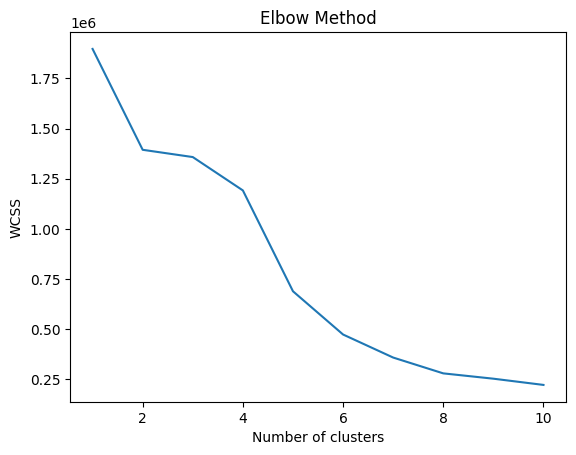

Number of clusters chosen by elbow method: 6


In [ ]:
from kneed import KneeLocator

# elbow plot
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,max_iter=100,n_init=1)
    kmeans.fit(SX)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# find elbow point
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
k = kl.elbow
print("Number of clusters chosen by elbow method:", k)


In [ ]:
SX.shape

(379399, 5)

In [ ]:
# using Kmeans
from sklearn.cluster import KMeans
k = 6
model = KMeans(n_clusters=k,init ='k-means++',max_iter=100,n_init=1)
model.fit(SX)

print("cluster no. of input documents, in the order they recieved")
print(model.labels_)

cluster no. of input documents, in the order they recieved
[5 0 0 ... 0 5 5]


array([5, 0, 0, ..., 0, 5, 5], dtype=int32)

In [ ]:
import numpy as np
from collections import Counter

# get the cluster labels
cluster_labels = model.labels_

# count the number of documents in each cluster
cluster_counts = Counter(cluster_labels)

# print the cluster number and the number of documents in each cluster
for cluster_num, count in cluster_counts.items():
    print(f"Cluster {cluster_num}: {count} documents")

# print the total number of clusters
total_clusters = len(cluster_counts)
print(f"\nTotal number of clusters: {total_clusters}")


Cluster 5: 112506 documents
Cluster 0: 92998 documents
Cluster 3: 23919 documents
Cluster 1: 149954 documents
Cluster 4: 7 documents
Cluster 2: 15 documents

Total number of clusters: 6


In [ ]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('database.csv')
df['TOTAL CASUALTIES'] = df['PERSONS INJURED'] + df['PEDESTRIANS INJURED'] + df['CYCLISTS INJURED'] + df['MOTORISTS INJURED'] + df['PERSONS KILLED'] + df['PEDESTRIANS KILLED'] + df['CYCLISTS KILLED'] + df['MOTORISTS KILLED']
df = df.drop(['PERSONS INJURED','PERSONS KILLED','PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED'], axis=1)
df.drop(df[(df['LONGITUDE'].isnull()) &
         (df['LATITUDE'].isnull()) &
         (df['TOTAL CASUALTIES'].eq(0))].index, inplace=True)
# now we fill the remaining missing values with the most frequent values which is the mode
for column in df.columns:
    df[column].fillna(df[column].mode()[0], inplace=True)
# Select relevant features
X = df[['LATITUDE', 'LONGITUDE', 'VEHICLE 1 TYPE','VEHICLE 1 FACTOR','TOTAL CASUALTIES']]
X
# machine learning only accept numnbers, or int or floats. it doesnt accept string or alphabet. so now we will have to encoding to change the strings to int. we will perform level encoding
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
X['VEHICLE 1 TYPE']= le1.fit_transform(X['VEHICLE 1 TYPE'])
X['VEHICLE 1 FACTOR']= le1.fit_transform(X['VEHICLE 1 FACTOR'])

# Normalize the data
scaler = StandardScaler()
SX = scaler.fit_transform(X)
SX
from kneed import KneeLocator

# elbow plot
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,max_iter=100,n_init=1)
    kmeans.fit(SX)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# find elbow point
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
k = kl.elbow
print("Number of clusters chosen by elbow method:", k)
# using Kmeans
from sklearn.cluster import KMeans
k = 6
model = KMeans(n_clusters=k,init ='k-means++',max_iter=100,n_init=1)
model.fit(SX)

print("cluster no. of input documents, in the order they recieved")
print(model.labels_)
import numpy as np
from collections import Counter

# get the cluster labels
cluster_labels = model.labels_

# count the number of documents in each cluster
cluster_counts = Counter(cluster_labels)

# print the cluster number and the number of documents in each cluster
for cluster_num, count in cluster_counts.items():
    print(f"Cluster {cluster_num}: {count} documents")

# print the total number of clusters
total_clusters = len(cluster_counts)
print(f"\nTotal number of clusters: {total_clusters}")




In [ ]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('database.csv')

# Calculate total casualties
df['TOTAL CASUALTIES'] = df[['PERSONS INJURED', 'PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PERSONS KILLED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED']].sum(axis=1)

# Drop irrelevant columns
df = df.drop(['PERSONS INJURED', 'PERSONS KILLED', 'PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED'], axis=1)

# Drop rows with missing coordinates and zero casualties
df = df.dropna(subset=['LATITUDE', 'LONGITUDE']).query("`TOTAL CASUALTIES` > 0")

# Fill remaining missing values with mode
df = df.fillna(df.mode().iloc[0])

# Select relevant features and perform label encoding
X = df[['LATITUDE', 'LONGITUDE', 'VEHICLE 1 TYPE', 'VEHICLE 1 FACTOR', 'TOTAL CASUALTIES']]
le = LabelEncoder()
X['VEHICLE 1 TYPE'] = le.fit_transform(X['VEHICLE 1 TYPE'])
X['VEHICLE 1 FACTOR'] = le.fit_transform(X['VEHICLE 1 FACTOR'])

# Normalize the data
scaler = StandardScaler()
SX = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, max_iter=100, n_init=1)
    kmeans.fit(SX)
    wcss.append(kmeans.inertia_)
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
k = kl.elbow

# Cluster the data using KMeans
model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1)
model.fit(SX)

# Get the cluster labels and counts
cluster_labels = model.labels_
cluster_counts = pd.Series(cluster_labels).value_counts()

# Print the results
print("Cluster no. of input documents, in the order they received:")
print(cluster_labels)
print("\nNumber of clusters chosen by elbow method:", k)
print("\nTotal number of clusters:", len(cluster_counts))
print("\nNumber of documents in each cluster:")
print(cluster_counts)


<ipython-input-31-f5d6cc1c208a>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['VEHICLE 1 TYPE'] = le.fit_transform(X['VEHICLE 1 TYPE'])
<ipython-input-31-f5d6cc1c208a>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['VEHICLE 1 FACTOR'] = le.fit_transform(X['VEHICLE 1 FACTOR'])


Cluster no. of input documents, in the order they received:
[3 1 1 ... 3 3 3]

Number of clusters chosen by elbow method: 5

Total number of clusters: 5

Number of documents in each cluster:
1    24987
3    21741
0    12565
4     5239
2        2
dtype: int64


<ipython-input-32-3f5f48e4af53>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['VEHICLE 1 TYPE', 'VEHICLE 1 FACTOR']] = X[['VEHICLE 1 TYPE', 'VEHICLE 1 FACTOR']].apply(le.fit_transform)


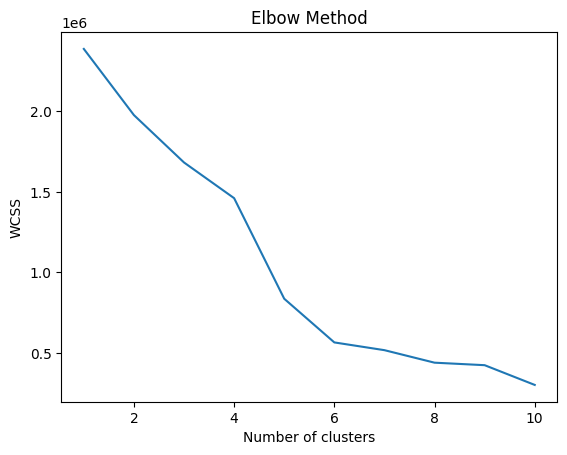

Number of clusters chosen by elbow method: 6
Number of documents in each cluster:
1    202873
3    113841
5     70810
2     65990
0     24203
4        15
dtype: int64

Total number of clusters: 6


In [ ]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('database.csv')

# Create a new column for total casualties
df['TOTAL CASUALTIES'] = df[['PERSONS INJURED', 'PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PERSONS KILLED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED']].sum(axis=1)

# Drop irrelevant columns
df.drop(['PERSONS INJURED', 'PERSONS KILLED', 'PEDESTRIANS INJURED', 'CYCLISTS INJURED', 'MOTORISTS INJURED', 'PEDESTRIANS KILLED', 'CYCLISTS KILLED', 'MOTORISTS KILLED'], axis=1, inplace=True)

# Drop rows with null values in longitude, latitude and total casualties
df.dropna(subset=['LONGITUDE', 'LATITUDE', 'TOTAL CASUALTIES'], how='all', inplace=True)

# Fill remaining missing values with mode
for column in df.columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Select relevant features
X = df[['LATITUDE', 'LONGITUDE', 'VEHICLE 1 TYPE','VEHICLE 1 FACTOR','TOTAL CASUALTIES']]

# Perform label encoding on categorical columns
le = LabelEncoder()
X[['VEHICLE 1 TYPE', 'VEHICLE 1 FACTOR']] = X[['VEHICLE 1 TYPE', 'VEHICLE 1 FACTOR']].apply(le.fit_transform)

# Normalize the data
scaler = StandardScaler()
SX = scaler.fit_transform(X)

# Elbow method to determine optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, max_iter=100, n_init=1)
    kmeans.fit(SX)
    wcss.append(kmeans.inertia_)

# Plot elbow curve and determine number of clusters
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
k = kl.elbow
print("Number of clusters chosen by elbow method:", k)

# Perform clustering using KMeans
model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1)
model.fit(SX)

# Get cluster labels
cluster_labels = model.labels_

# Count the number of documents in each cluster
cluster_counts = pd.Series(cluster_labels).value_counts()

# Print the number of documents in each cluster and total number of clusters
print(f"Number of documents in each cluster:\n{cluster_counts}")
print(f"\nTotal number of clusters: {len(cluster_counts)}")


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
# extract the longitude and latitude columns
X = df[['longitude', 'latitude']]

# choose the number of clusters
k = 5

# fit KMeans model to the data
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)

# get the cluster labels for each document
cluster_labels = kmeans.predict(X)

# initialize a dictionary to keep track of total casualties for each cluster
cluster_casualties = {i: 0 for i in range(k)}

# loop through each document and add its total casualties to the corresponding cluster's count
for i, label in enumerate(cluster_labels):
    casualties = df.iloc[i]['total_casualties']  # replace 'total_casualties' with the actual column name in your data
    cluster_casualties[label] += casualties

# print the total casualties for each cluster
print(cluster_casualties)


KeyError: ignored

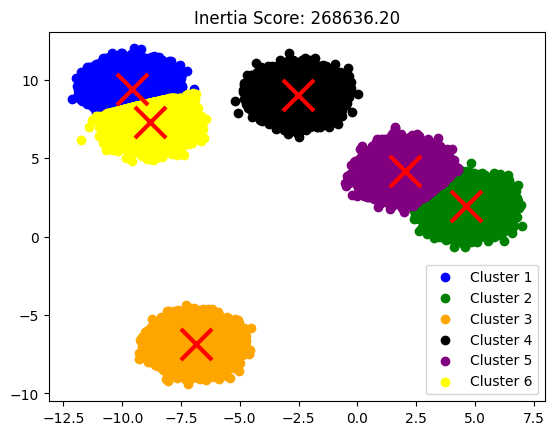

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

# generating sample data
SX, _ = make_blobs(n_samples=379399, centers=6, cluster_std=0.6, random_state=42)

# perform clustering
kmeans = KMeans(n_clusters=6, init='k-means++', max_iter=100, n_init=1)
kmeans.fit(SX)
centroids = kmeans.cluster_centers_
inertia = kmeans.inertia_

# assigning labels to each data point
labels = kmeans.predict(SX)

colors = ['blue', 'green', 'orange', 'black', 'purple', 'yellow']
# map labels to colors and plot the data points and centroids with category labels
for label in np.unique(labels):
    plt.scatter(SX[labels == label, 0], SX[labels == label, 1], c=colors[label], label='Cluster {}'.format(label+1))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=500, linewidths=3, color="red")

# Add title and legend to the plot
plt.title('Inertia Score: {:.2f}'.format(inertia))
plt.legend()
plt.show()




/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


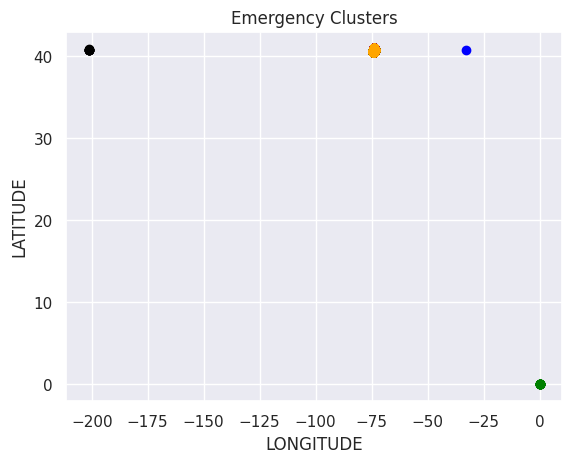

In [ ]:

# KMeans clustering with optimal k value
k = 6
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
kmeans.fit(SX)
df['cluster'] = kmeans.labels_

# Visualize clusters
colors = ['red', 'green', 'blue', 'yellow','orange','black']
for i in range(k):
    cluster_df = df[df['cluster'] == i]
    plt.scatter(cluster_df['LONGITUDE'], cluster_df['LATITUDE'], color=colors[i])
plt.title('Emergency Clusters')
plt.xlabel('LONGITUDE')
plt.ylabel('LATITUDE')
plt.show()
